In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("EarthPulse - NDVI basics")
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)

EarthPulse - NDVI basics
NumPy: 2.4.6
Pandas: 3.0.6


In [9]:
dates = pd.date_range(
    start="2025-01-01",
    periods=12,
    freq="MS"
)

ndvi = np.array([
    0.42,
    0.45,
    0.50,
    0.58,
    0.65,
    0.70,
    0.72,
    0.68,
    0.61,
    0.55,
    0.48,
    0.44
])

df = pd.DataFrame({
    "date": dates,
    "ndvi": ndvi
})

df

,date,ndvi
0,2025-01-01,0.42
1,2025-02-01,0.45
2,2025-03-01,0.50
3,2025-04-01,0.58
4,2025-05-01,0.65
5,2025-06-01,0.70
6,2025-07-01,0.72
7,2025-08-01,0.68
8,2025-09-01,0.61
9,2025-10-01,0.55


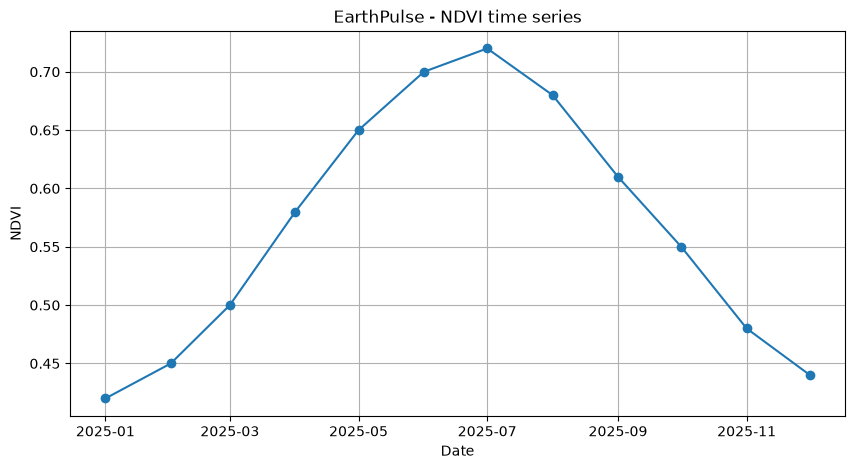

In [10]:
plt.figure(figsize=(10, 5))

plt.plot(
    df["date"],
    df["ndvi"],
    marker="o"
)

plt.title("EarthPulse - NDVI time series")
plt.xlabel("Date")
plt.ylabel("NDVI")
plt.grid(True)

plt.show()

In [11]:
# Calcoliamo il valore medio della serie NDVI.
# Questo rappresenta una semplice baseline di riferimento.

baseline_ndvi = df["ndvi"].mean()

print(f"Baseline NDVI: {baseline_ndvi:.3f}")

Baseline NDVI: 0.565


In [12]:
# Differenza tra NDVI osservato e baseline

df["ndvi_change"] = df["ndvi"] - baseline_ndvi

df

,date,ndvi,ndvi_change
0,2025-01-01,0.42,-0.145
1,2025-02-01,0.45,-0.115
2,2025-03-01,0.50,-0.065
3,2025-04-01,0.58,0.015
4,2025-05-01,0.65,0.085
5,2025-06-01,0.70,0.135
6,2025-07-01,0.72,0.155
7,2025-08-01,0.68,0.115
8,2025-09-01,0.61,0.045
9,2025-10-01,0.55,-0.015


In [13]:
# Variazione percentuale rispetto alla baseline

df["ndvi_change_pct"] = (
    (df["ndvi"] - baseline_ndvi) / baseline_ndvi
) * 100

df


,date,ndvi,ndvi_change,ndvi_change_pct
0,2025-01-01,0.42,-0.145,-25.663717
1,2025-02-01,0.45,-0.115,-20.353982
2,2025-03-01,0.50,-0.065,-11.504425
3,2025-04-01,0.58,0.015,2.654867
4,2025-05-01,0.65,0.085,15.044248
5,2025-06-01,0.70,0.135,23.893805
6,2025-07-01,0.72,0.155,27.433628
7,2025-08-01,0.68,0.115,20.353982
8,2025-09-01,0.61,0.045,7.964602
9,2025-10-01,0.55,-0.015,-2.654867


In [20]:
# Formattiamo la variazione percentuale per una visualizzazione più leggibile.
# Manteniamo il valore numerico originale in "change_pct".

df_event["change_pct_display"] = (
    df_event["change_pct"].round(1).astype(str) + "%"
)

df_event[
    ["date", "ndvi", "change_pct", "change_pct_display", "status"]
]

,date,ndvi,change_pct,change_pct_display,status
0,2025-01-01,0.42,-25.663717,-25.7%,Decrease
1,2025-02-01,0.45,-20.353982,-20.4%,Decrease
2,2025-03-01,0.50,-11.504425,-11.5%,Stable
3,2025-04-01,0.58,2.654867,2.7%,Stable
4,2025-05-01,0.65,15.044248,15.0%,Increase
5,2025-06-01,0.70,23.893805,23.9%,Increase
6,2025-07-01,0.45,-20.353982,-20.4%,Decrease
7,2025-08-01,0.40,-29.203540,-29.2%,Decrease
8,2025-09-01,0.38,-32.743363,-32.7%,Decrease
9,2025-10-01,0.42,-25.663717,-25.7%,Decrease


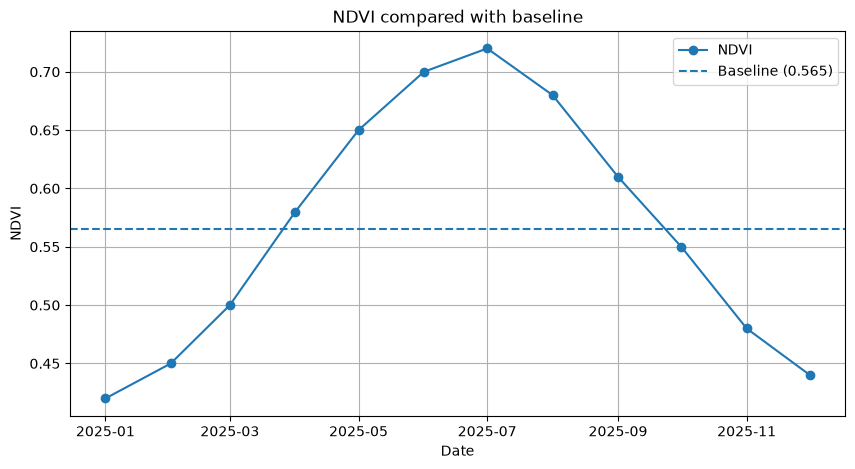

In [14]:
plt.figure(figsize=(10, 5))

plt.plot(
    df["date"],
    df["ndvi"],
    marker="o",
    label="NDVI"
)

plt.axhline(
    baseline_ndvi,
    linestyle="--",
    label=f"Baseline ({baseline_ndvi:.3f})"
)

plt.title("NDVI compared with baseline")
plt.xlabel("Date")
plt.ylabel("NDVI")
plt.legend()
plt.grid(True)

plt.show()

In [15]:
# Creiamo una seconda serie temporale che simula
# un cambiamento improvviso nella vegetazione.
#
# Fino a giugno: situazione normale
# Da luglio: forte diminuzione dell'NDVI

ndvi_event = np.array([
    0.42,
    0.45,
    0.50,
    0.58,
    0.65,
    0.70,
    0.45,
    0.40,
    0.38,
    0.42,
    0.46,
    0.44
])

df_event = pd.DataFrame({
    "date": dates,
    "ndvi": ndvi_event
})

df_event

,date,ndvi
0,2025-01-01,0.42
1,2025-02-01,0.45
2,2025-03-01,0.50
3,2025-04-01,0.58
4,2025-05-01,0.65
5,2025-06-01,0.70
6,2025-07-01,0.45
7,2025-08-01,0.40
8,2025-09-01,0.38
9,2025-10-01,0.42


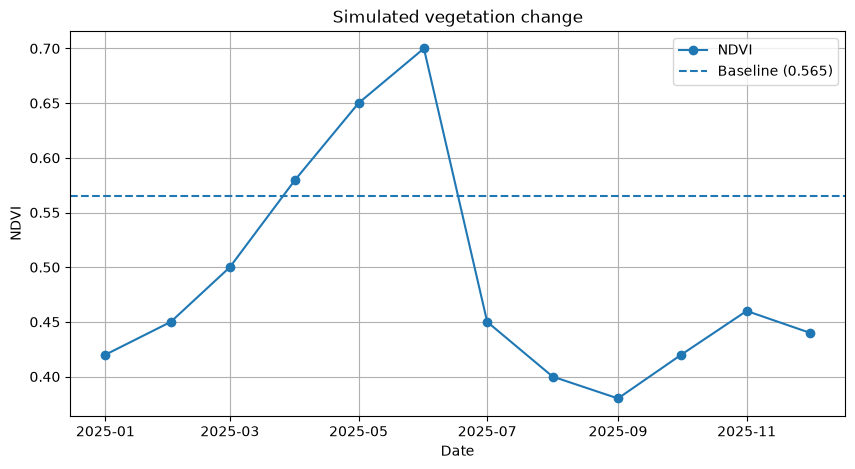

In [16]:
plt.figure(figsize=(10, 5))

plt.plot(
    df_event["date"],
    df_event["ndvi"],
    marker="o",
    label="NDVI"
)

plt.axhline(
    baseline_ndvi,
    linestyle="--",
    label=f"Baseline ({baseline_ndvi:.3f})"
)

plt.title("Simulated vegetation change")
plt.xlabel("Date")
plt.ylabel("NDVI")
plt.legend()
plt.grid(True)

plt.show()

In [17]:
# Soglia utilizzata per identificare una variazione significativa.
# In questa prima versione è volutamente semplice.

threshold = 15

df_event["change_pct"] = (
    (df_event["ndvi"] - baseline_ndvi)
    / baseline_ndvi
) * 100

df_event["significant_change"] = (
    df_event["change_pct"].abs() >= threshold
)

df_event

,date,ndvi,change_pct,significant_change
0,2025-01-01,0.42,-25.663717,True
1,2025-02-01,0.45,-20.353982,True
2,2025-03-01,0.50,-11.504425,False
3,2025-04-01,0.58,2.654867,False
4,2025-05-01,0.65,15.044248,True
5,2025-06-01,0.70,23.893805,True
6,2025-07-01,0.45,-20.353982,True
7,2025-08-01,0.40,-29.203540,True
8,2025-09-01,0.38,-32.743363,True
9,2025-10-01,0.42,-25.663717,True


In [18]:
def classify_change(change_pct, threshold=15):
    """
    Classifica la variazione NDVI rispetto alla baseline.
    """

    if change_pct <= -threshold:
        return "Decrease"

    elif change_pct >= threshold:
        return "Increase"

    else:
        return "Stable"


df_event["status"] = df_event["change_pct"].apply(classify_change)

df_event

,date,ndvi,change_pct,significant_change,status
0,2025-01-01,0.42,-25.663717,True,Decrease
1,2025-02-01,0.45,-20.353982,True,Decrease
2,2025-03-01,0.50,-11.504425,False,Stable
3,2025-04-01,0.58,2.654867,False,Stable
4,2025-05-01,0.65,15.044248,True,Increase
5,2025-06-01,0.70,23.893805,True,Increase
6,2025-07-01,0.45,-20.353982,True,Decrease
7,2025-08-01,0.40,-29.203540,True,Decrease
8,2025-09-01,0.38,-32.743363,True,Decrease
9,2025-10-01,0.42,-25.663717,True,Decrease


In [19]:
df_event[
    ["date", "ndvi", "change_pct", "status"]
]

,date,ndvi,change_pct,status
0,2025-01-01,0.42,-25.663717,Decrease
1,2025-02-01,0.45,-20.353982,Decrease
2,2025-03-01,0.50,-11.504425,Stable
3,2025-04-01,0.58,2.654867,Stable
4,2025-05-01,0.65,15.044248,Increase
5,2025-06-01,0.70,23.893805,Increase
6,2025-07-01,0.45,-20.353982,Decrease
7,2025-08-01,0.40,-29.203540,Decrease
8,2025-09-01,0.38,-32.743363,Decrease
9,2025-10-01,0.42,-25.663717,Decrease


In [21]:
# Numero minimo di osservazioni consecutive necessarie
# per considerare il cambiamento persistente.

min_consecutive = 2

df_event["is_decrease"] = (
    df_event["change_pct"] <= -threshold
)

df_event[[
    "date",
    "ndvi",
    "change_pct",
    "is_decrease"
]]

,date,ndvi,change_pct,is_decrease
0,2025-01-01,0.42,-25.663717,True
1,2025-02-01,0.45,-20.353982,True
2,2025-03-01,0.50,-11.504425,False
3,2025-04-01,0.58,2.654867,False
4,2025-05-01,0.65,15.044248,False
5,2025-06-01,0.70,23.893805,False
6,2025-07-01,0.45,-20.353982,True
7,2025-08-01,0.40,-29.203540,True
8,2025-09-01,0.38,-32.743363,True
9,2025-10-01,0.42,-25.663717,True


In [22]:
# Identifichiamo i gruppi consecutivi di valori True/False.

groups = (
    df_event["is_decrease"] != df_event["is_decrease"].shift()
).cumsum()

df_event["consecutive_decrease"] = (
    df_event["is_decrease"]
    .groupby(groups)
    .cumsum()
)

df_event[[
    "date",
    "ndvi",
    "change_pct",
    "is_decrease",
    "consecutive_decrease"
]]

,date,ndvi,change_pct,is_decrease,consecutive_decrease
0,2025-01-01,0.42,-25.663717,True,1
1,2025-02-01,0.45,-20.353982,True,2
2,2025-03-01,0.50,-11.504425,False,0
3,2025-04-01,0.58,2.654867,False,0
4,2025-05-01,0.65,15.044248,False,0
5,2025-06-01,0.70,23.893805,False,0
6,2025-07-01,0.45,-20.353982,True,1
7,2025-08-01,0.40,-29.203540,True,2
8,2025-09-01,0.38,-32.743363,True,3
9,2025-10-01,0.42,-25.663717,True,4


In [23]:
df_event["change_event"] = (
    df_event["consecutive_decrease"] >= min_consecutive
)

df_event[[
    "date",
    "ndvi",
    "change_pct",
    "consecutive_decrease",
    "change_event"
]]

,date,ndvi,change_pct,consecutive_decrease,change_event
0,2025-01-01,0.42,-25.663717,1,False
1,2025-02-01,0.45,-20.353982,2,True
2,2025-03-01,0.50,-11.504425,0,False
3,2025-04-01,0.58,2.654867,0,False
4,2025-05-01,0.65,15.044248,0,False
5,2025-06-01,0.70,23.893805,0,False
6,2025-07-01,0.45,-20.353982,1,False
7,2025-08-01,0.40,-29.203540,2,True
8,2025-09-01,0.38,-32.743363,3,True
9,2025-10-01,0.42,-25.663717,4,True


In [24]:
event_dates = df_event.loc[
    df_event["change_event"],
    "date"
]

if len(event_dates) > 0:
    event_start = event_dates.iloc[0]
    print("Possible change event detected.")
    print(f"Start date: {event_start:%d %B %Y}")
else:
    print("No persistent change detected.")

Possible change event detected.
Start date: 01 February 2025
